# Taxi Cruising Model — Calibration Notebook
**CASA0011 — Agent-Based Modelling, Coursework 2**  
*Evaluating the Impact of Heterogeneous Cruising Strategies on Urban Congestion: An ABM of Midtown Manhattan*

This notebook covers two calibration tasks:
1. **TLC Demand-Intensity Field** — Deriving the three-tier `demand-intensity` input from January 2025 yellow taxi trip records (evening rush hour, 17:00–18:00).
2. **Baseline Speed Calibration** — Analysing BehaviorSpace experiment results to determine the steady-state `baseline-speed-value` at each vehicle count (`num-cars`).

---
## 0. Imports

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium

---
## Part 1: TLC Yellow Taxi Pickup Demand

**Goal:** Aggregate January 2025 yellow taxi pickups during evening rush hour (17:00–18:00) to produce a pickup density map of Manhattan, then collapse the spatial signal into the three discrete `demand-intensity` tiers used by the model (1.0 / 0.5 / 0.2).

**Data sources:**
- `yellow_tripdata_2025-01.parquet` — TLC Trip Record Data (January 2025)
- `taxi_zones/taxi_zones.shp` — NYC Taxi Zone shapefile

### 1.1 Load and Filter TLC Trip Records

In [2]:
# Load raw TLC data
file_path = "../Data/yellow_tripdata_2025-01.parquet"
df = pd.read_parquet(file_path)

# Parse datetime and filter for evening rush hour (17:00–18:00)
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
rush_hour = df[df['tpep_pickup_datetime'].dt.hour.isin([17, 18])]

print(f"Total records: {len(df):,}")
print(f"Evening rush hour records (17:00–18:00): {len(rush_hour):,}")

Total records: 3,475,226
Evening rush hour records (17:00–18:00): 521,469


### 1.2 Aggregate Pickup Counts by Taxi Zone

In [3]:
# Count pickups per taxi zone
demand_counts = (
    rush_hour['PULocationID']
    .value_counts()
    .reset_index()
)
demand_counts.columns = ['LocationID', 'PickupCount']
demand_counts['LocationID'] = demand_counts['LocationID'].astype(str)

# Preview top zones
print("Top 10 zones by pickup count:")
display(demand_counts.head(10))

Top 10 zones by pickup count:


,LocationID,PickupCount
0,161,33837
1,237,25471
2,236,24425
3,162,23464
4,230,19029
5,132,18541
6,163,16873
7,234,15914
8,186,15907
9,142,15844


### 1.3 Join with Spatial Data and Compute Demand Density

In [4]:
# Load taxi zone shapefile
zones_gdf = gpd.read_file('../Data/taxi_zones/taxi_zones.shp')

# Calculate area in km² using a metric CRS
zones_gdf['area_km2'] = zones_gdf.to_crs(epsg=3857).area / 1e6

# Reproject to WGS84 for Folium compatibility
zones_gdf = zones_gdf.to_crs(epsg=4326)

# Filter to Manhattan and merge with demand counts
manhattan_zones = zones_gdf[zones_gdf['borough'] == 'Manhattan'].copy()
manhattan_zones['LocationID'] = manhattan_zones['LocationID'].astype(str)

manhattan_demand_gdf = manhattan_zones.merge(
    demand_counts, on='LocationID', how='left'
)
manhattan_demand_gdf['PickupCount'] = manhattan_demand_gdf['PickupCount'].fillna(0)

# Compute demand density (pickups per km²)
manhattan_demand_gdf['Demand_Density'] = (
    manhattan_demand_gdf['PickupCount'] / manhattan_demand_gdf['area_km2']
)

print(f"Manhattan zones: {len(manhattan_demand_gdf)}")
print("\nDemand density summary:")
display(manhattan_demand_gdf['Demand_Density'].describe().round(1))

d:\Users\17902\anaconda3\envs\urbsim\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Manhattan zones: 69

Demand density summary:


count       69.0
mean      6235.7
std       7117.2
min          0.0
25%        652.3
50%       4658.0
75%       8339.2
max      29947.3
Name: Demand_Density, dtype: float64

### 1.4 Interactive Choropleth Map (Folium)

In [5]:
# Initialise map centred on Midtown Manhattan
m = folium.Map(
    location=[40.7589, -73.9851],
    zoom_start=14,
    tiles='cartodbpositron'
)

# Choropleth layer: demand density
folium.Choropleth(
    geo_data=manhattan_demand_gdf.to_json(),
    data=manhattan_demand_gdf,
    columns=['LocationID', 'Demand_Density'],
    key_on='feature.properties.LocationID',
    fill_color='YlOrRd',
    fill_opacity=0.4,
    line_opacity=0.1,
    legend_name='Demand Density (Pickups per km², 17:00–18:00, Jan 2025)'
).add_to(m)

# Hover tooltips
folium.GeoJson(
    manhattan_demand_gdf,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'transparent'},
    tooltip=folium.GeoJsonTooltip(
        fields=['LocationID', 'zone', 'PickupCount', 'Demand_Density'],
        aliases=['Zone ID:', 'Zone Name:', 'Total Pickups:', 'Density (per km²):'],
        localize=True
    )
).add_to(m)

m

### 1.5 Three-Tier Demand-Intensity Abstraction

The model focuses on the Midtown corridor (39th–50th St, 10th Ave to Park Ave). These zones correspond directly to the high / mid / low demand tiers encoded as `demand-intensity` values (1.0 / 0.5 / 0.2) in the NetLogo model, capturing the east-west demand gradient visible in the empirical data.

---
## Part 2: Baseline Speed Calibration

**Goal:** Identify the steady-state `global-average-speed` for each `num-cars` value from BehaviorSpace runs that varied vehicle count with background traffic only (no taxis or FHVs). These values are hardcoded as `baseline-speed-value` in the NetLogo model and used to normalise the *Speed Ratio vs Baseline* plot.

**Data source:** `experiment-baseline-speed-table.csv` — BehaviorSpace output table (6-row header, skip with `skiprows=6`).

### 2.1 Load BehaviorSpace Output

In [7]:
# Load BehaviorSpace table (NetLogo adds a 6-row metadata header)
baseline_raw = pd.read_csv(
    "../Data/experiment-baseline-speed-table.csv",
    skiprows=6
)

# Retain only the columns needed
cols = ['num-cars', '[step]', 'global-average-speed']
baseline_speed = baseline_raw[cols].copy()

print(f"Rows: {len(baseline_speed):,}")
print(f"num-cars values: {sorted(baseline_speed['num-cars'].unique())}")
print(f"Steps range: {baseline_speed['[step]'].min()} – {baseline_speed['[step]'].max()}")
display(baseline_speed.head())

Rows: 70,140
num-cars values: [np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1100), np.int64(1200), np.int64(1300), np.int64(1400), np.int64(1500)]
Steps range: 0 – 500


,num-cars,[step],global-average-speed
0,200,0,0.0
1,200,0,0.0
2,200,0,0.0
3,200,0,0.0
4,200,1,0.0


### 2.2 Speed Trajectories by Vehicle Count

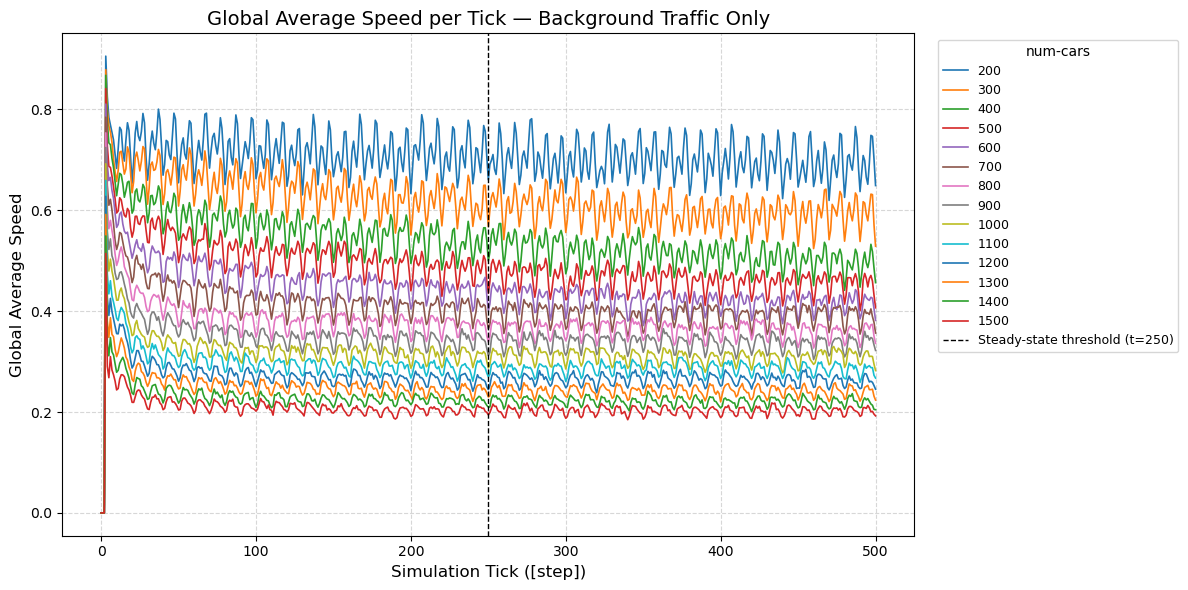

In [8]:
# Pivot: mean speed per tick per num-cars (averaging across BehaviorSpace repetitions)
df_pivot = (
    baseline_speed
    .groupby(['[step]', 'num-cars'])['global-average-speed']
    .mean()
    .unstack()
)

# Plot trajectories
fig, ax = plt.subplots(figsize=(12, 6))
df_pivot.plot(ax=ax, linewidth=1.2)

# Mark the steady-state threshold
STEADY_STATE_THRESHOLD = 250
ax.axvline(STEADY_STATE_THRESHOLD, color='black', linestyle='--', linewidth=1, label='Steady-state threshold (t=250)')

ax.set_title('Global Average Speed per Tick — Background Traffic Only', fontsize=14)
ax.set_xlabel('Simulation Tick ([step])', fontsize=12)
ax.set_ylabel('Global Average Speed', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='num-cars', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### 2.3 Steady-State Baseline Speed Values

Ticks after `t = 250` are treated as steady state (initial transient dissipated). The mean speed in this window becomes the `baseline-speed-value` for each `num-cars` setting.

In [9]:
STEADY_STATE_THRESHOLD = 250

steady_state_df = baseline_speed[baseline_speed['[step]'] > STEADY_STATE_THRESHOLD]

steady_results = (
    steady_state_df
    .groupby('num-cars')['global-average-speed']
    .agg(mean='mean', std='std', n='count')
    .round(4)
    .reset_index()
)
steady_results.columns = ['num-cars', 'baseline-speed-value', 'std', 'n_ticks']

print("Steady-State Baseline Speed Values (for NetLogo baseline-speed-value):")
display(steady_results)

Steady-State Baseline Speed Values (for NetLogo baseline-speed-value):


,num-cars,baseline-speed-value,std,n_ticks
0,200,0.6992,0.0479,2500
1,300,0.5976,0.0422,2500
2,400,0.5126,0.0354,2500
3,500,0.4615,0.0306,2500
4,600,0.4210,0.0269,2500
5,700,0.3933,0.0245,2500
6,800,0.3634,0.0225,2500
7,900,0.3383,0.0204,2500
8,1000,0.3096,0.0181,2500
9,1100,0.2865,0.0166,2500


### 2.4 Speed–Density Relationship

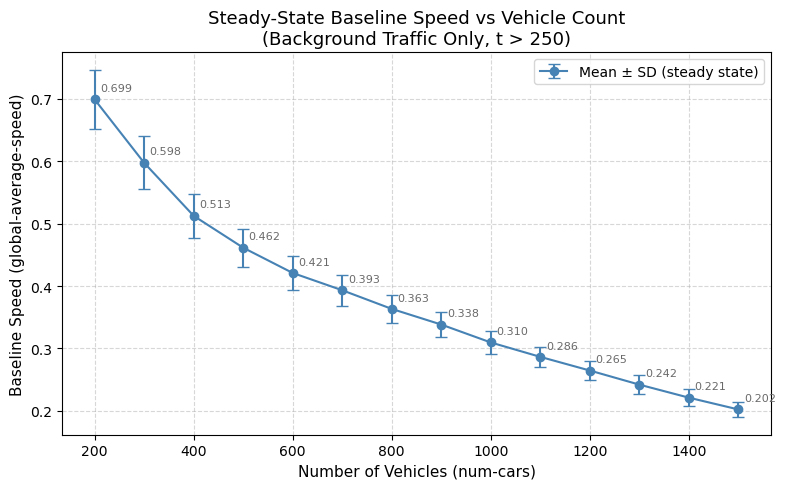

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    steady_results['num-cars'],
    steady_results['baseline-speed-value'],
    yerr=steady_results['std'],
    fmt='o-', color='steelblue', capsize=4, linewidth=1.5, markersize=6,
    label='Mean ± SD (steady state)'
)

ax.set_title('Steady-State Baseline Speed vs Vehicle Count\n(Background Traffic Only, t > 250)', fontsize=13)
ax.set_xlabel('Number of Vehicles (num-cars)', fontsize=11)
ax.set_ylabel('Baseline Speed (global-average-speed)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10)

# Annotate each point with its value
for _, row in steady_results.iterrows():
    ax.annotate(
        f"{row['baseline-speed-value']:.3f}",
        xy=(row['num-cars'], row['baseline-speed-value']),
        xytext=(4, 6), textcoords='offset points', fontsize=8, color='dimgrey'
    )

plt.tight_layout()
plt.show()

### 2.5 Summary Table for NetLogo Implementation

These values should be hardcoded into the NetLogo model as the `baseline-speed-value` reporter, selected by `num-cars` at initialisation.

In [11]:
print("NetLogo baseline-speed-value lookup table:")
print("-" * 40)
for _, row in steady_results.iterrows():
    print(f"  num-cars = {int(row['num-cars']):>4d}  →  baseline-speed-value = {row['baseline-speed-value']:.4f}")

NetLogo baseline-speed-value lookup table:
----------------------------------------
  num-cars =  200  →  baseline-speed-value = 0.6992
  num-cars =  300  →  baseline-speed-value = 0.5976
  num-cars =  400  →  baseline-speed-value = 0.5126
  num-cars =  500  →  baseline-speed-value = 0.4615
  num-cars =  600  →  baseline-speed-value = 0.4210
  num-cars =  700  →  baseline-speed-value = 0.3933
  num-cars =  800  →  baseline-speed-value = 0.3634
  num-cars =  900  →  baseline-speed-value = 0.3383
  num-cars = 1000  →  baseline-speed-value = 0.3096
  num-cars = 1100  →  baseline-speed-value = 0.2865
  num-cars = 1200  →  baseline-speed-value = 0.2646
  num-cars = 1300  →  baseline-speed-value = 0.2420
  num-cars = 1400  →  baseline-speed-value = 0.2211
  num-cars = 1500  →  baseline-speed-value = 0.2022
